# Introduction

The purpose of this notebook is to work through the stock market related data to figure out what data exists and how we can combine everything.

The pipeline for stock data has not yet been started. There are two files: `all_stocks_5yr.csv` and `sector_industry.csv`. Discussion of data acquisition will be included for documentation. There's a third, much larger dataset, `stock_dataset.csv`, from hugging face that will also be included.

Essentially, the goal of this exploration is to label existing data, figure out date ranges, and start looking for the "useful" variables.

## Setup

We will be using common data science libraries listed below. Additionally, we plan to use `plotnine` as the data viz library to adhere to the grammar of graphics.

In [ ]:
import pandas as pd
from plotnine import *

import re

from sector_study.config import RAW_DATA_DIR, EXTERNAL_DATA_DIR

print("setup complete!")

## Data

All acquired stock data is included in this notebook. The stock data part of the pipeline is still underdeveloped, so this notebook will also demonstrate how the pipeline is programmed.

There are three data sources containing stock data. `all_stocks_5yr.csv` is from [camnugent/sandp500](https://www.kaggle.com/datasets/camnugent/sandp500) on Kaggle. It contains data for all S&P 500 stocks over a five year period. `sector_industry_info.csv` and `stock_dataset.csv` are from HuggingFace, [yeong-hwan/ticker-sector-industry](https://huggingface.co/datasets/yeong-hwan/ticker-sector-industry) and [Adilbai/stock-dataset](https://huggingface.co/datasets/Adilbai/stock-dataset) respectively. `sector_industry_info.csv` is a ticker-industry-sector lookup table to be used for labeling observations in the other two files. `stock_dataset.csv` also spans 5 years and contains daily observations on the S&P 500 stocks, but I'm not yet sure if the span overlaps with `all_stocks_5yr.csv`. However, `stock_dataset.csv` contains 73 variables per observation, so maybe the granularity of information is better or worse.

In [2]:
all_stocks = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("all_stocks_5yr.csv"))
sector_industry = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("sector_industry_info.csv"), index_col=0)
stocks_dataset = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("stock_dataset.csv"))

In [3]:
print(f"{all_stocks.shape}\n{all_stocks.columns}\n")
print(f"{sector_industry.shape}\n{sector_industry.columns}\n")
print(f"{stocks_dataset.shape}\n{stocks_dataset.columns}\n")

(619040, 7)
Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')

(500, 3)
Index(['Ticker', 'Sector', 'Industry'], dtype='object')

(620095, 73)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Ticker', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50',
       'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position',
       'Volatility', 'Price_Change', 'Price_Change_5d', 'High_Low_Ratio',
       'Open_Close_Ratio', 'Volume_SMA', 'Volume_Ratio', 'Close_lag_1',
       'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10',
       'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5',
       'Volume_lag_10', 'Price_Change_lag_1', 'Price_Change_lag_2',
       'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10',
       'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
       'MACD_lag_1', 'MACD_lag_2', 'MA

This confirms a few assumptions above. The lookup table contains all 500 tickers. The two stock datasets both contain five years worth of data. The `stocks_datset` does have 73 columns. Somethign interesting to note is that the 73 variables can kinda be grouped up into raw data and subcategories for statistics/metrics that change the time span for their calculation.

# Exploration

In [54]:
print(all_stocks["date"].min())
print(all_stocks["date"].max())
print(stocks_dataset["Date"].min())
print(stocks_dataset["Date"].max())

2013-02-08
2018-02-07
2020-07-15 00:00:00-04:00
2025-06-27 00:00:00-04:00


What a shame that 2019-2020 is not recorded. Perhaps it would be worth it to find that data myself in order to make the most of our headline data. Thankfully, the datasets do not intersect, so no data is duplicated. Plotting is hardly a good use of time for this data without making use of categorical variables.

Fortunately, the date-time variables are much easier to work with in these datasets.

A merge should give us some more to work with.

In [55]:
sector_industry.head()

,Ticker,Sector,Industry
0,MMM,Industrials,Conglomerates
1,AOS,Industrials,Specialty Industrial Machinery
2,ABT,Healthcare,Medical Devices
3,ABBV,Healthcare,Drug Manufacturers - General
4,ACN,Technology,Information Technology Services


In [56]:
all_stocks.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [57]:
early_sectors = pd.merge(all_stocks, sector_industry, left_on="Name", right_on="Ticker", how="left")
early_sectors.head()

,date,open,high,low,close,volume,Name,Ticker,Sector,Industry
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL,NaN,NaN,NaN
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL,NaN,NaN,NaN
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL,NaN,NaN,NaN
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL,NaN,NaN,NaN
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL,NaN,NaN,NaN


In [58]:
early_sectors[["Name", "Ticker"]].describe()

,Name,Ticker
count,619040,459739
unique,505,371
top,ZTS,YUM
freq,1259,1259


Hmm, looks like there are some differences between the `Name` column and the `Ticker` column. My assumption was that it was a bijection. It turns out that this is not the case. I'm guessing that the `sector_industry` data was collected more recently. Since the relationship is not a bijection, then I'm thinking that the cause is time. So there is some fluctuation in stock membership in the index fund...

In [59]:
all_stocks_name = set(all_stocks["Name"].unique())
print(all_stocks_name)
stocks_data_ticker = set(stocks_dataset["Ticker"].unique())
print(stocks_data_ticker)

{'VZ', 'FIS', 'REGN', 'IT', 'SPG', 'VRSK', 'XRX', 'DISCK', 'PEG', 'BBY', 'CHRW', 'MTB', 'LLL', 'AES', 'MCO', 'HBAN', 'DVN', 'FRT', 'SNI', 'REG', 'JNPR', 'EXC', 'INFO', 'ES', 'HES', 'RHT', 'DRI', 'ZION', 'C', 'LNC', 'FITB', 'BAX', 'ZTS', 'VMC', 'D', 'IRM', 'PNR', 'TAP', 'AVB', 'CINF', 'SIG', 'HOG', 'EOG', 'MAT', 'SYF', 'PYPL', 'A', 'RCL', 'VNO', 'CHD', 'OMC', 'GGP', 'PCG', 'KSU', 'MS', 'UHS', 'USB', 'GT', 'INCY', 'IP', 'PX', 'MMC', 'CHTR', 'LEG', 'RRC', 'EMN', 'BLL', 'COF', 'CBOE', 'PPL', 'AAP', 'ARE', 'DE', 'ADP', 'NBL', 'BWA', 'LNT', 'NSC', 'IDXX', 'EXPE', 'APTV', 'FB', 'CCL', 'TMO', 'COL', 'XOM', 'PHM', 'DISH', 'PSX', 'COTY', 'GILD', 'AYI', 'UNM', 'CFG', 'PWR', 'AIG', 'TXN', 'AVGO', 'IQV', 'OKE', 'GM', 'BK', 'TPR', 'DFS', 'ADBE', 'MRO', 'FOX', 'NTRS', 'CSRA', 'APD', 'ACN', 'HP', 'PDCO', 'ANSS', 'AFL', 'NWL', 'PNW', 'EW', 'EXR', 'SWKS', 'TSN', 'ABBV', 'AAL', 'HLT', 'MU', 'ALXN', 'CAH', 'NFX', 'MA', 'MSFT', 'GOOG', 'WLTW', 'TXT', 'EL', 'PLD', 'MAS', 'SRE', 'AMT', 'SBAC', 'LEN', 'NKE', 

In [60]:
pd.Series(list(all_stocks_name.intersection(stocks_data_ticker))).count()

np.int64(368)

In [61]:
pd.Series(list(set(sector_industry["Ticker"].unique()).intersection(stocks_data_ticker))).count()

np.int64(493)

According to the intersections, it looks like the `sector_industry` data was pulled during/after the COVID shutdown, but before `stocks_dataset` was observed.

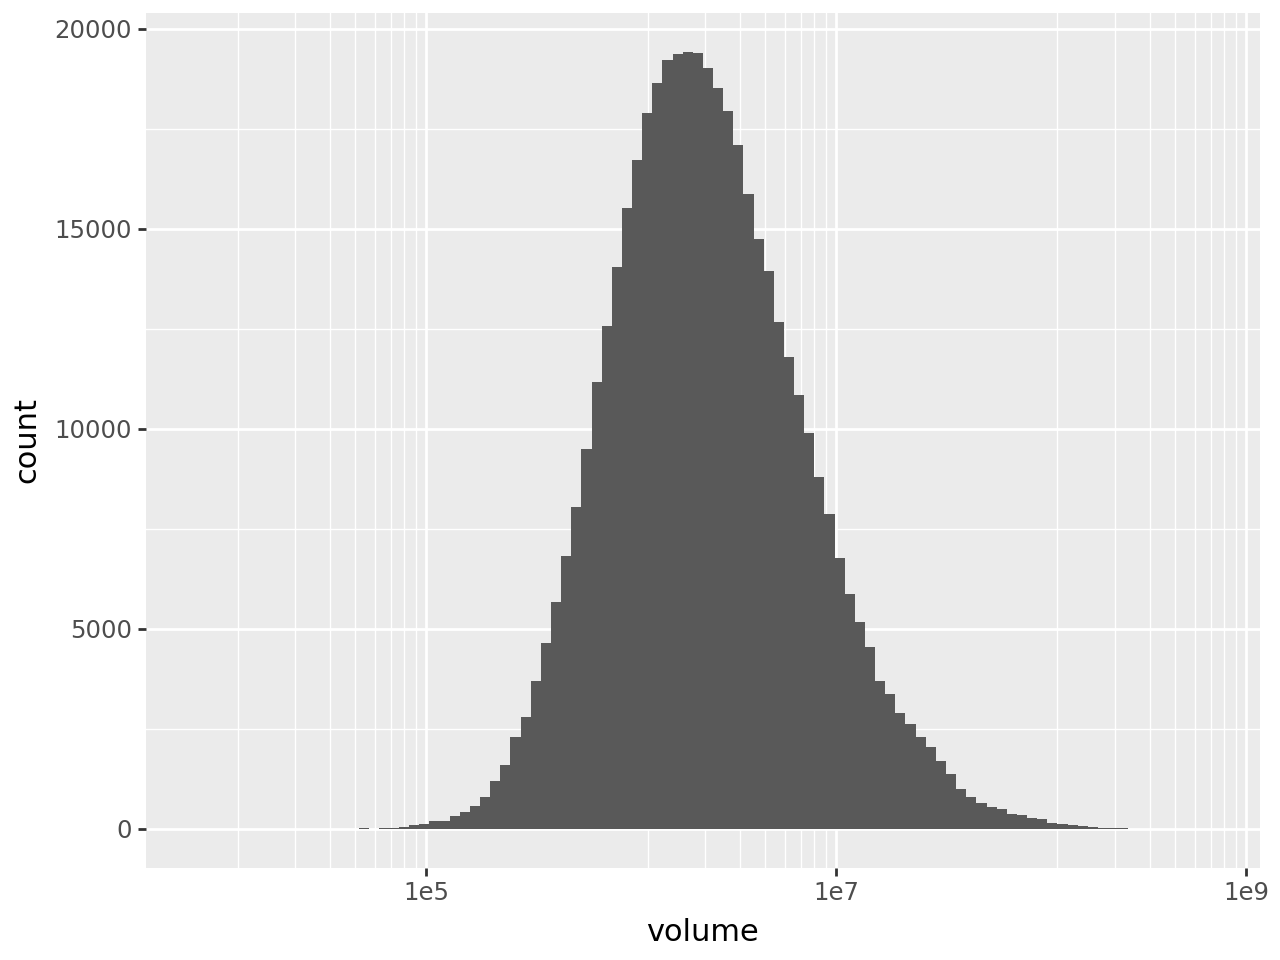

In [62]:
interesting_columns = ["date", "open", "volume", "Name", "Sector"]
df = early_sectors[interesting_columns]

(
  ggplot(df.dropna())
  + geom_histogram(aes(x="volume"), bins=100)
  + scale_x_log10()
)

Didn't expect that... So the log of volume is normally distributed.

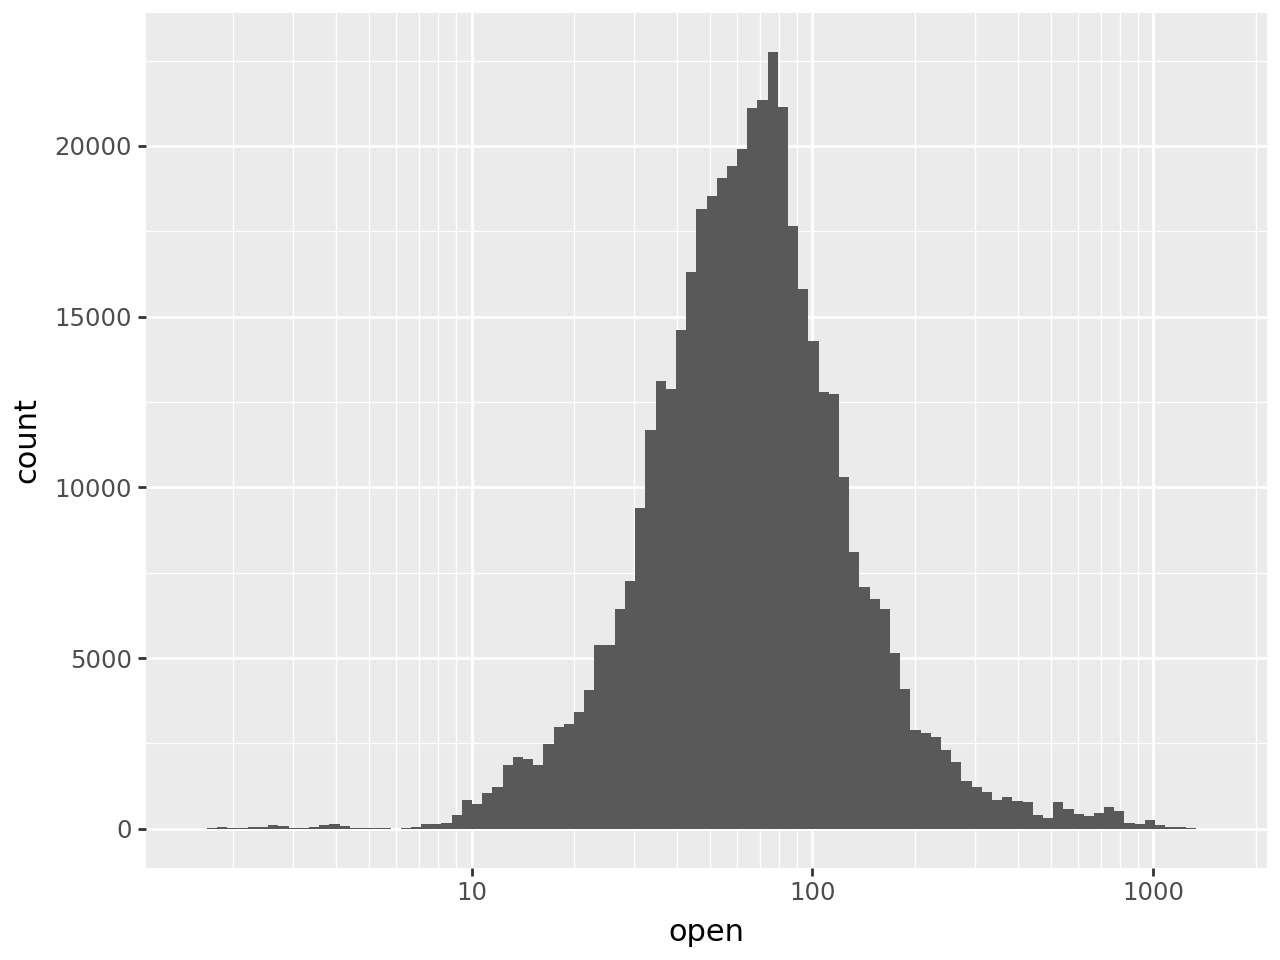

In [63]:
interesting_columns = ["date", "open", "volume", "Name", "Sector"]
df = early_sectors[interesting_columns].dropna()

(
  ggplot(df)
  + geom_histogram(aes(x="open"), bins=100)
  + scale_x_log10()
)

I guess a better way to explain this normal distribution would be to refer to the ~500 "independent" variables. I think what's more interesting is the logarithmic relationship.

Perhaps there's something that can be said about the sectors? Let's look at small multiples below.

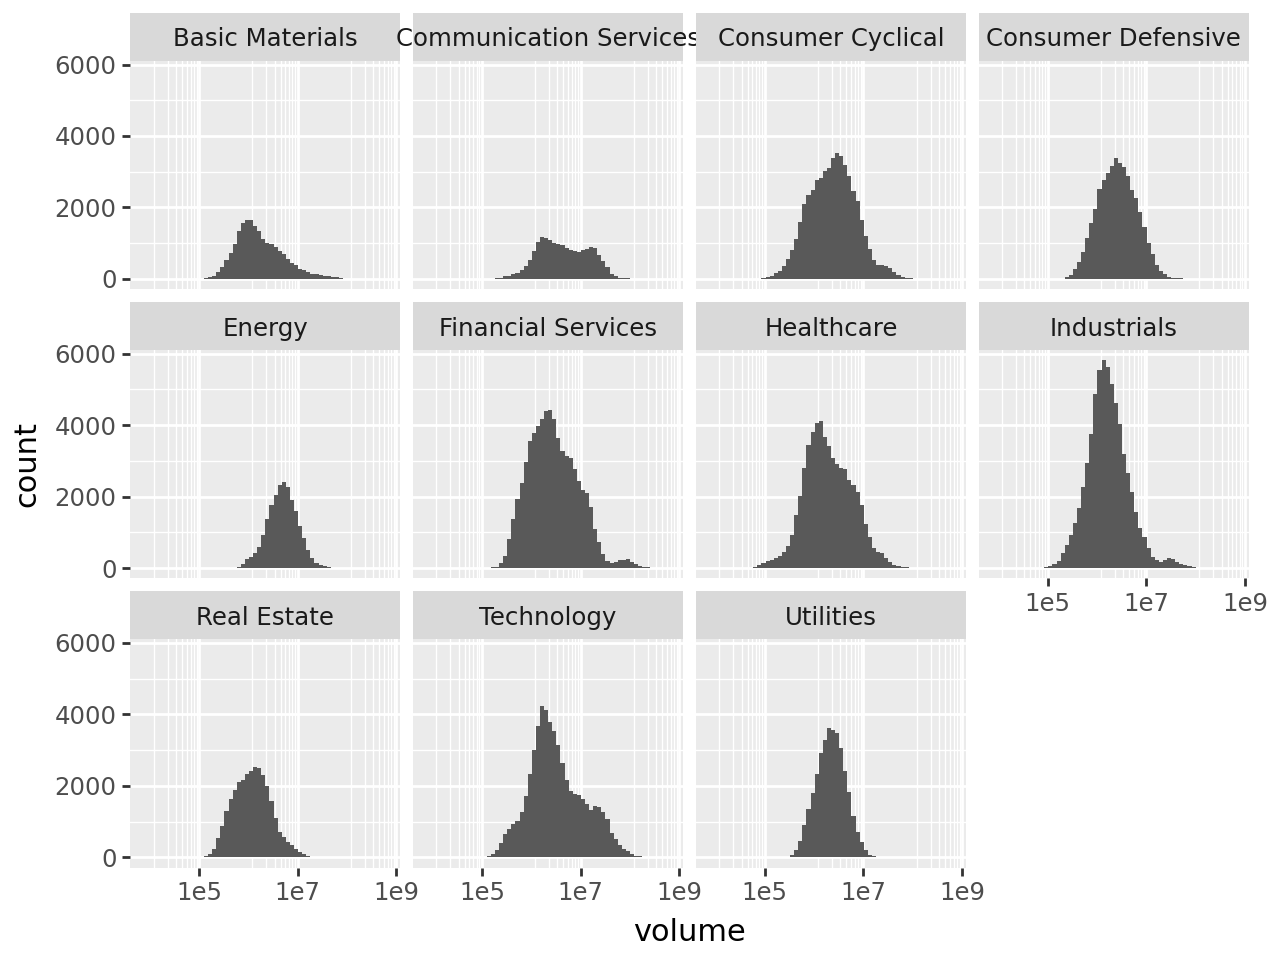

In [85]:
interesting_columns = ["date", "open", "volume", "Name", "Sector"]
df = early_sectors[interesting_columns].dropna()

(
  ggplot(df)
  + geom_histogram(aes(x="volume"), bins=60)
  + facet_wrap("Sector")
  + scale_x_log10()
)

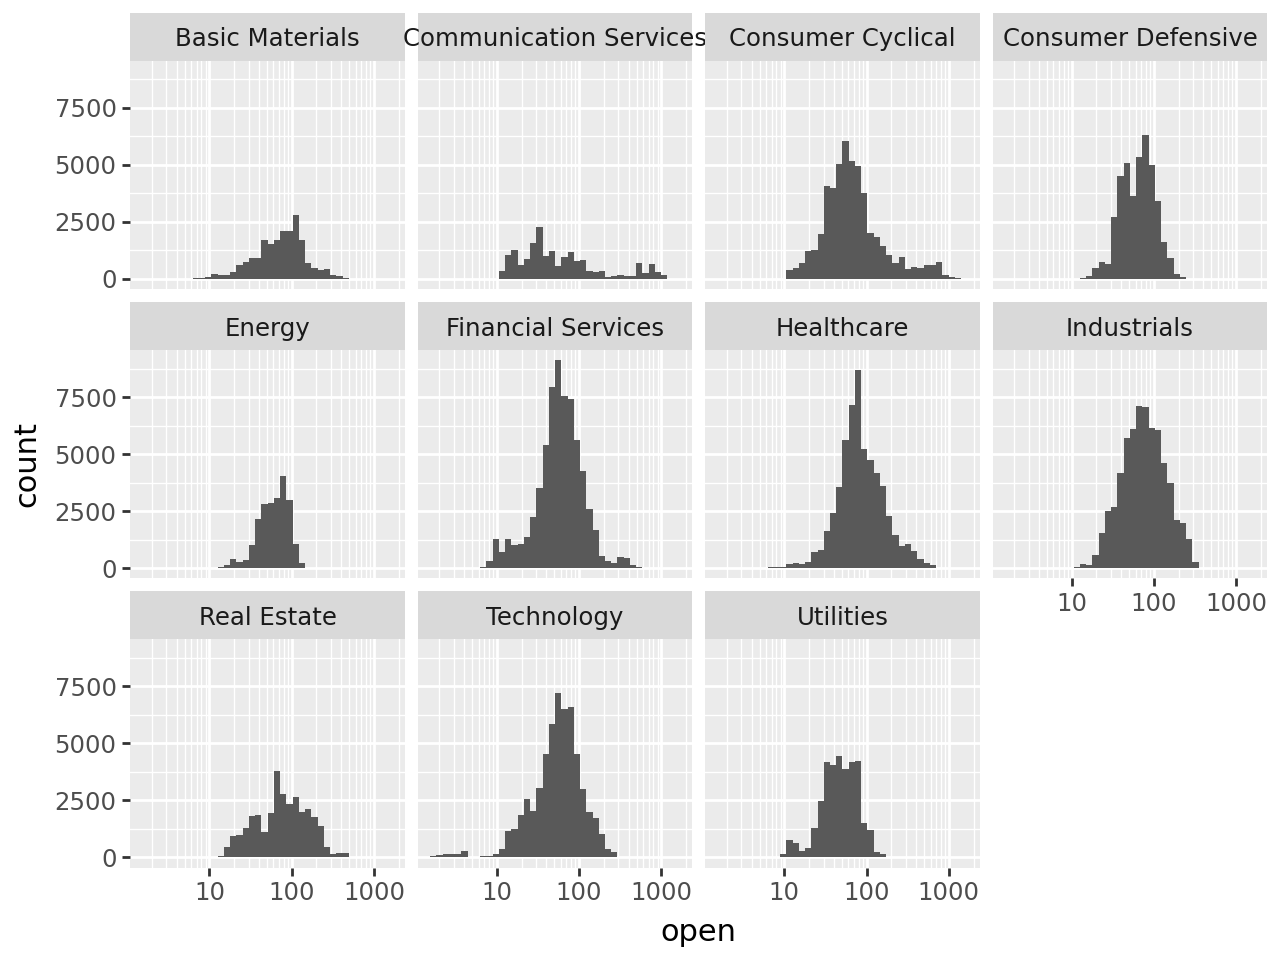

In [90]:
interesting_columns = ["date", "open", "volume", "Name", "Sector"]
df = early_sectors[interesting_columns].dropna()

(
  ggplot(df)
  + geom_histogram(aes(x="open"), bins=40)
  + facet_wrap("Sector")
  + scale_x_log10()
)

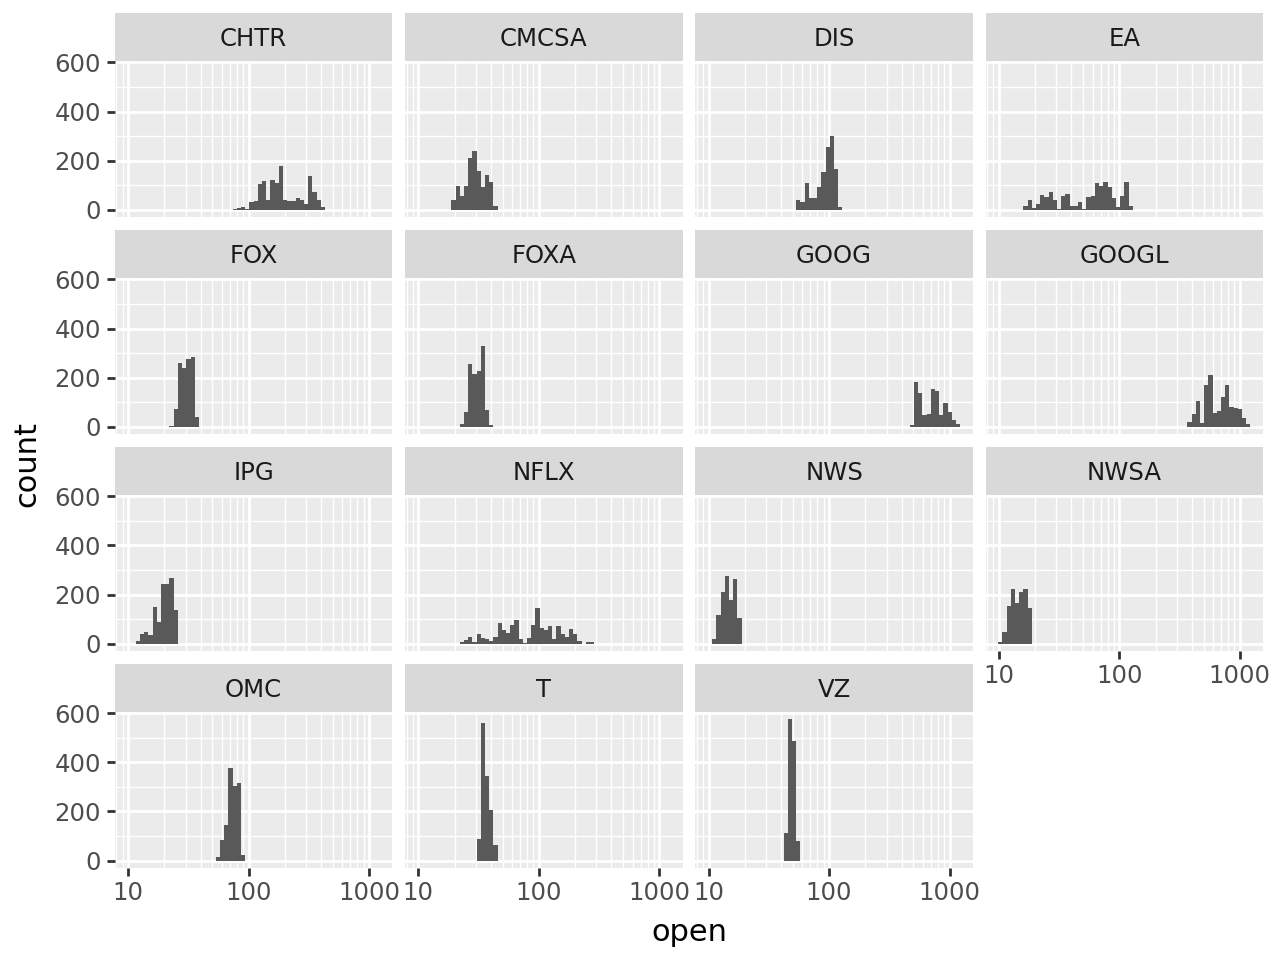

In [92]:
(
  ggplot(df.loc[df["Sector"] == "Communication Services"])
  + geom_histogram(aes(x="open"), bins=60)
  + facet_wrap("Name")
  + scale_x_log10()
)

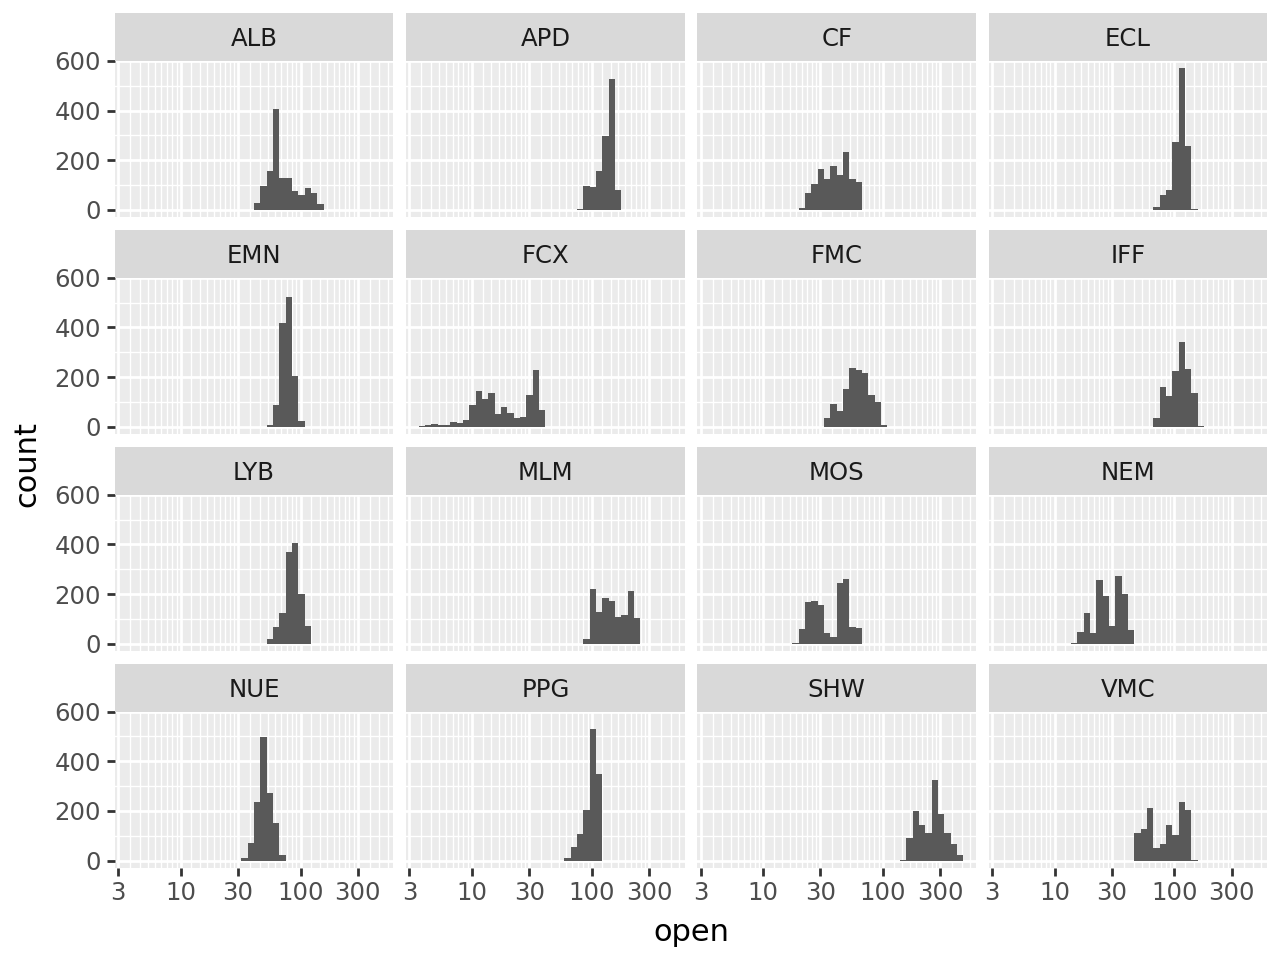

In [94]:
(
  ggplot(df.loc[df["Sector"] == "Basic Materials"])
  + geom_histogram(aes(x="open"), bins=40)
  + facet_wrap("Name")
  + scale_x_log10()
)

So some sectors, like Communication Services, are not normally distributed, but still fit on the log scale. Something like this can be attributed to sectors that do not have a typical stock price throughout the sector. That may be an important connection down the line during NLP.